# 颜色特征提取


### 0.环境、依赖与路径初始化


In [3]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

from scipy import stats
from scipy.stats import mannwhitneyu, ks_2samp, ttest_ind
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import label as sk_label, regionprops
from skimage.color import rgb2lab

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path('.')
IMAGE_DIR = BASE_DIR / 'processed_image'
MASK_DIR  = BASE_DIR / 'mask'
LABEL_CSV = BASE_DIR / 'label.csv'
sns.set(font='SimHei', font_scale=1.2) # 设置字体

print('BASE_DIR:', BASE_DIR.resolve())
print('Images found:', len(list(IMAGE_DIR.glob('*.jpg'))))
print('Masks found: ', len(list(MASK_DIR.glob('*.jpg'))))

BASE_DIR: E:\biplab_py\project\Project\Data_Proj2
Images found: 600
Masks found:  600


## 第一节：数据读取与标签构建

- 从 `label.csv` 读取样本标签（nv / mel / vasc）
- 为第一阶段任务构建二值标签：`vasc=1`，`non-vasc=0`

In [4]:
# --- 读取标签 ---
df_label = pd.read_csv(LABEL_CSV)
df_label['image_id'] = df_label['image_id'].astype(str)
label_map = dict(zip(df_label['image_id'], df_label['dx']))

# --- 枚举所有图像，解析 image_id ---
records = []
for img_path in sorted(IMAGE_DIR.glob('*.jpg')):
    stem = img_path.stem                         # e.g. '100_aug1' or '1'
    base_id = re.split(r'_aug', stem)[0]         # strip _aug1/_aug2
    if base_id not in label_map:
        continue
    dx = label_map[base_id]
    mask_path = MASK_DIR / f'mask_{stem}.jpg'
    records.append({
        'stem': stem,
        'base_id': base_id,
        'img_path': img_path,
        'mask_path': mask_path,
        'dx': dx,
        'label': 1 if dx == 'vasc' else 0   # Stage-1 binary label
    })

df_meta = pd.DataFrame(records)
print(f'共 {len(df_meta)} 个样本（含增强）')
print('\n原始标签分布:')
print(df_meta['dx'].value_counts())
print('\n二值标签分布 (1=vasc, 0=non-vasc):')
print(df_meta['label'].value_counts())

# # --- 可视化类别分布 ---
# fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# df_meta['dx'].value_counts().plot.bar(ax=axes[0], color=['steelblue','salmon','mediumseagreen'], edgecolor='k')
# axes[0].set_title('三分类样本分布'); axes[0].set_xlabel('类别'); axes[0].set_ylabel('样本数'); axes[0].tick_params(rotation=0)

# df_meta['label'].value_counts().rename({0:'non-vasc',1:'vasc'}).plot.bar(
#     ax=axes[1], color=['steelblue','salmon'], edgecolor='k')
# axes[1].set_title('Stage-1 二值标签分布'); axes[1].set_xlabel('类别'); axes[1].set_ylabel('样本数'); axes[1].tick_params(rotation=0)
# plt.tight_layout(); plt.show()

共 600 个样本（含增强）

原始标签分布:
dx
nv      300
mel     210
vasc     90
Name: count, dtype: int64

二值标签分布 (1=vasc, 0=non-vasc):
label
0    510
1     90
Name: count, dtype: int64


## 第二节：特征提取


In [5]:

def extract_features(img_path, mask_path):
    """
    仅提取颜色特征。

    特征来源：
    1. 基础通道统计量：
       RGB, normalized RGB, HSV, Ohta I1I2I3, Gevers l1l2l3,
       CIE L*u*v*, CIE L*a*b*, YCbCr
       每个通道计算 max, min, mean, var, std, skew。

    2. 区域性统计：
       对 RGB, normalized RGB, HSV, Ohta, Gevers, Luv 六个空间，
       计算病灶区、内周边、外周边之间的均值/标准差比值与差值。

    3. 颜色不对称度：
       对 R, G, B 三通道，基于亮度质心和主轴方向计算折叠不对称度。

    4. 质心距离：
       对 RGB, normalized RGB, HSV, Ohta, Gevers, Luv 六个空间，
       每个通道计算几何质心与亮度质心距离，并用病灶等效直径归一化。

    5. LUV 直方图距离：
       在 Luv 空间中使用 4×8×8 bins，
       计算病灶区、内周边、外周边两两之间的 L1 / L2 距离。

    6. 特定颜色指标：
       红斑指数 R / (G + B) 的均值与方差；
       HSV Hue 在红色区间 [0°,20°] ∪ [340°,360°] 的像素比例。
       
    """

    feats = {}
    eps = 1e-6

    # ============================================================
    # 1. 读取图像和 mask
    # ============================================================

    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        return None

    img_rgb_uint8 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = img_rgb_uint8.astype(np.float32)

    H_img, W_img = img_rgb.shape[:2]

    mask_raw = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) if mask_path.exists() else None

    if mask_raw is not None:
        if mask_raw.shape[:2] != img_rgb.shape[:2]:
            mask_raw = cv2.resize(mask_raw, (W_img, H_img), interpolation=cv2.INTER_NEAREST)
        mask = (mask_raw > 127).astype(np.uint8)
    else:
        mask = np.ones((H_img, W_img), dtype=np.uint8)

    lesion_mask = mask.astype(bool)

    if lesion_mask.sum() == 0:
        return None

    # ============================================================
    # 2. 基础工具函数
    # ============================================================

    def safe_skew(vals):
        vals = np.asarray(vals, dtype=np.float32)
        if len(vals) < 3:
            return 0.0
        if np.nanstd(vals) < eps:
            return 0.0
        v = stats.skew(vals, nan_policy='omit')
        return float(0.0 if np.isnan(v) else v)

    def add_channel_stats(prefix, img3, channel_names, region_mask):
        """
        对一个 3 通道颜色空间计算每个通道的：
        max, min, mean, var, std, skew。
        """
        for i, ch_name in enumerate(channel_names):
            vals = img3[:, :, i][region_mask].astype(np.float32)

            if vals.size == 0:
                vals = img3[:, :, i].reshape(-1).astype(np.float32)

            feats[f'{prefix}_{ch_name}_max'] = float(np.max(vals))
            feats[f'{prefix}_{ch_name}_min'] = float(np.min(vals))
            feats[f'{prefix}_{ch_name}_mean'] = float(np.mean(vals))
            feats[f'{prefix}_{ch_name}_var'] = float(np.var(vals))
            feats[f'{prefix}_{ch_name}_std'] = float(np.std(vals))
            feats[f'{prefix}_{ch_name}_skew'] = safe_skew(vals)

    def region_mean_std(img3, channel_names, region_mask):
        """
        返回某个区域内每个通道的 mean 和 std。
        """
        out = {}

        for i, ch_name in enumerate(channel_names):
            vals = img3[:, :, i][region_mask].astype(np.float32)

            if vals.size == 0:
                vals = img3[:, :, i].reshape(-1).astype(np.float32)

            out[ch_name] = {
                'mean': float(np.mean(vals)),
                'std': float(np.std(vals))
            }

        return out

    def calc_normalized_rgb(rgb):
        """
        normalized RGB:
        r = R / (R + G + B)
        g = G / (R + G + B)
        b = B / (R + G + B)
        """
        R = rgb[:, :, 0]
        G = rgb[:, :, 1]
        B = rgb[:, :, 2]
        S = R + G + B + eps

        r = R / S
        g = G / S
        b = B / S

        return np.stack([r, g, b], axis=-1).astype(np.float32)

    def calc_ohta(rgb):
        """
        Ohta I1I2I3 color space.
        常用定义：
        I1 = (R + G + B) / 3
        I2 = (R - B) / 2
        I3 = (2G - R - B) / 4
        """
        R = rgb[:, :, 0]
        G = rgb[:, :, 1]
        B = rgb[:, :, 2]

        I1 = (R + G + B) / 3.0
        I2 = (R - B) / 2.0
        I3 = (2.0 * G - R - B) / 4.0

        return np.stack([I1, I2, I3], axis=-1).astype(np.float32)

    def calc_gevers_l123(rgb):
        """
        Gevers & Smeulders l1l2l3 color features.

        常用颜色不变量定义：
        l1 = (R - G)^2 / (R + G + B)
        l2 = (R - B)^2 / (R + G + B)
        l3 = (G - B)^2 / (R + G + B)
        """
        R = rgb[:, :, 0]
        G = rgb[:, :, 1]
        B = rgb[:, :, 2]

        S = R + G + B + eps

        l1 = ((R - G) ** 2) / S
        l2 = ((R - B) ** 2) / S
        l3 = ((G - B) ** 2) / S

        return np.stack([l1, l2, l3], axis=-1).astype(np.float32)

    # ============================================================
    # 3. 构建所有颜色空间
    # ============================================================

    rgb = img_rgb

    norm_rgb = calc_normalized_rgb(rgb)

    hsv_uint8 = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2HSV)
    hsv = hsv_uint8.astype(np.float32)
    # OpenCV 中 H 范围是 0-179，这里转成角度 0-358，方便后续 Hue 红色区间判断
    hsv[:, :, 0] = hsv[:, :, 0] * 2.0

    ohta = calc_ohta(rgb)

    gevers = calc_gevers_l123(rgb)

    luv_uint8 = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2Luv)
    luv = luv_uint8.astype(np.float32)

    lab_uint8 = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2Lab)
    lab = lab_uint8.astype(np.float32)

    ycrcb_uint8 = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2YCrCb)
    ycrcb = ycrcb_uint8.astype(np.float32)

    # OpenCV 输出顺序是 Y, Cr, Cb，这里重排成 Y, Cb, Cr
    ycbcr = np.stack(
        [
            ycrcb[:, :, 0],
            ycrcb[:, :, 2],
            ycrcb[:, :, 1]
        ],
        axis=-1
    ).astype(np.float32)

    color_spaces_all = {
        'RGB': (rgb, ['R', 'G', 'B']),
        'rgb': (norm_rgb, ['r', 'g', 'b']),
        'HSV': (hsv, ['H', 'S', 'V']),
        'Ohta': (ohta, ['I1', 'I2', 'I3']),
        'Gevers': (gevers, ['l1', 'l2', 'l3']),
        'Luv': (luv, ['L_luv', 'u_luv', 'v_luv']),
        'Lab': (lab, ['L_lab', 'a_lab', 'b_lab']),
        'YCbCr': (ycbcr, ['Y', 'Cb', 'Cr'])
    }

    # ============================================================
    # 4. 3.1 基础通道统计量
    # ============================================================

    for space_name, (space_img, ch_names) in color_spaces_all.items():
        add_channel_stats(
            prefix=space_name,
            img3=space_img,
            channel_names=ch_names,
            region_mask=lesion_mask
        )

    # ============================================================
    # 5. 构建病灶区、内周边、外周边
    # ============================================================
    #
    # 文档定义：
    # 内/外周边面积各为病灶面积的 20%，并与病灶边界保留 10% 过渡带。
    #
    # 这里采用基于 mask 外部距离的近似实现：
    # 1. 对病灶外部像素计算到病灶边界的距离；
    # 2. 跳过距离最近、面积约为病灶面积 10% 的过渡带；
    # 3. 再取面积约为病灶面积 20% 的像素作为内周边；
    # 4. 再取面积约为病灶面积 20% 的像素作为外周边。

    def build_peripheral_regions(lesion_mask, transition_ratio=0.10, ring_ratio=0.20):
        outside_mask = ~lesion_mask
        lesion_area = int(lesion_mask.sum())

        if lesion_area <= 0 or outside_mask.sum() == 0:
            empty = np.zeros_like(lesion_mask, dtype=bool)
            return empty, empty

        dist_outside = cv2.distanceTransform(
            outside_mask.astype(np.uint8),
            distanceType=cv2.DIST_L2,
            maskSize=5
        )

        outside_indices = np.argwhere(outside_mask)
        outside_dist = dist_outside[outside_mask]

        order = np.argsort(outside_dist)
        outside_indices_sorted = outside_indices[order]

        n_transition = int(round(transition_ratio * lesion_area))
        n_inner = int(round(ring_ratio * lesion_area))
        n_outer = int(round(ring_ratio * lesion_area))

        start_inner = min(n_transition, len(outside_indices_sorted))
        end_inner = min(start_inner + n_inner, len(outside_indices_sorted))
        end_outer = min(end_inner + n_outer, len(outside_indices_sorted))

        inner_mask = np.zeros_like(lesion_mask, dtype=bool)
        outer_mask = np.zeros_like(lesion_mask, dtype=bool)

        if end_inner > start_inner:
            inner_idx = outside_indices_sorted[start_inner:end_inner]
            inner_mask[inner_idx[:, 0], inner_idx[:, 1]] = True

        if end_outer > end_inner:
            outer_idx = outside_indices_sorted[end_inner:end_outer]
            outer_mask[outer_idx[:, 0], outer_idx[:, 1]] = True

        return inner_mask, outer_mask

    inner_mask, outer_mask = build_peripheral_regions(lesion_mask)

    # ============================================================
    # 6. 3.2.1 区域性统计：均值/标准差的比值和差值
    # ============================================================

    regional_spaces = {
        'RGB': (rgb, ['R', 'G', 'B']),
        'rgb': (norm_rgb, ['r', 'g', 'b']),
        'HSV': (hsv, ['H', 'S', 'V']),
        'Ohta': (ohta, ['I1', 'I2', 'I3']),
        'Gevers': (gevers, ['l1', 'l2', 'l3']),
        'Luv': (luv, ['L_luv', 'u_luv', 'v_luv'])
    }

    for space_name, (space_img, ch_names) in regional_spaces.items():
        lesion_stats = region_mean_std(space_img, ch_names, lesion_mask)
        inner_stats = region_mean_std(space_img, ch_names, inner_mask)
        outer_stats = region_mean_std(space_img, ch_names, outer_mask)

        region_stats = {
            'lesion': lesion_stats,
            'inner': inner_stats,
            'outer': outer_stats
        }

        pair_defs = [
            ('outer', 'inner'),
            ('outer', 'lesion'),
            ('inner', 'lesion')
        ]

        for ch_name in ch_names:
            for stat_name in ['mean', 'std']:
                for region_a, region_b in pair_defs:
                    a = region_stats[region_a][ch_name][stat_name]
                    b = region_stats[region_b][ch_name][stat_name]

                    feats[f'{space_name}_{ch_name}_{stat_name}_{region_a}_div_{region_b}'] = float(a / (b + eps))
                    feats[f'{space_name}_{ch_name}_{stat_name}_{region_a}_minus_{region_b}'] = float(a - b)

    # ============================================================
    # 7. 3.2.2 RGB 颜色不对称度
    # ============================================================

    def color_asymmetry_for_channel(channel_img, lesion_mask, channel_name):
        """
        基于单个颜色通道计算颜色不对称度。

        步骤：
        1. 使用该通道像素值作为权重，计算亮度质心；
        2. 基于加权二阶矩估计主轴；
        3. 沿主轴方向折叠，计算对应位置亮度差；
        4. 沿垂直主轴方向折叠，计算对应位置亮度差。

        输出：
        - axis0_pct: 沿主轴折叠后的归一化差异
        - axis0_sum: 沿主轴折叠后的平均绝对差异
        - axis90_pct: 沿垂直主轴折叠后的归一化差异
        - axis90_sum: 沿垂直主轴折叠后的平均绝对差异
        """
        ys, xs = np.where(lesion_mask)
        vals = channel_img[lesion_mask].astype(np.float32)

        if len(vals) < 5 or np.sum(vals) <= eps:
            feats[f'asym_{channel_name}_axis0_pct'] = 0.0
            feats[f'asym_{channel_name}_axis0_sum'] = 0.0
            feats[f'asym_{channel_name}_axis90_pct'] = 0.0
            feats[f'asym_{channel_name}_axis90_sum'] = 0.0
            return

        weights = vals + eps

        cx = np.sum(xs * weights) / np.sum(weights)
        cy = np.sum(ys * weights) / np.sum(weights)

        x0 = xs - cx
        y0 = ys - cy

        cov_xx = np.sum(weights * x0 * x0) / np.sum(weights)
        cov_yy = np.sum(weights * y0 * y0) / np.sum(weights)
        cov_xy = np.sum(weights * x0 * y0) / np.sum(weights)

        cov = np.array([[cov_xx, cov_xy], [cov_xy, cov_yy]], dtype=np.float32)

        eigvals, eigvecs = np.linalg.eigh(cov)
        main_axis = eigvecs[:, np.argmax(eigvals)]

        ux, uy = main_axis[0], main_axis[1]

        # 投影到主轴 u 和垂直轴 v
        u = x0 * ux + y0 * uy
        v = -x0 * uy + y0 * ux

        def folded_difference(coord_a, coord_b, values, fold_axis='u'):
            """
            将投影坐标离散化，对折后比较镜像位置亮度差。
            """
            qa = np.round(coord_a).astype(int)
            qb = np.round(coord_b).astype(int)

            d = {}

            for a, b, val in zip(qa, qb, values):
                key = (a, b)
                d[key] = d.get(key, 0.0) + float(val)

            visited = set()
            total_abs_diff = 0.0

            for key, val in d.items():
                if key in visited:
                    continue

                a, b = key

                if fold_axis == 'u':
                    mirror_key = (-a, b)
                else:
                    mirror_key = (a, -b)

                mirror_val = d.get(mirror_key, 0.0)

                total_abs_diff += abs(val - mirror_val)

                visited.add(key)
                visited.add(mirror_key)

            pct = total_abs_diff / (np.sum(values) + eps)
            mean_abs = total_abs_diff / (len(values) + eps)

            return float(pct), float(mean_abs)

        axis0_pct, axis0_sum = folded_difference(u, v, vals, fold_axis='u')
        axis90_pct, axis90_sum = folded_difference(u, v, vals, fold_axis='v')

        feats[f'asym_{channel_name}_axis0_pct'] = axis0_pct
        feats[f'asym_{channel_name}_axis0_sum'] = axis0_sum
        feats[f'asym_{channel_name}_axis90_pct'] = axis90_pct
        feats[f'asym_{channel_name}_axis90_sum'] = axis90_sum

    color_asymmetry_for_channel(rgb[:, :, 0], lesion_mask, 'R')
    color_asymmetry_for_channel(rgb[:, :, 1], lesion_mask, 'G')
    color_asymmetry_for_channel(rgb[:, :, 2], lesion_mask, 'B')

    # ============================================================
    # 8. 3.2.3 质心距离：6 个颜色空间 × 3 通道 = 18 个
    # ============================================================

    def add_centroid_distance_features(space_name, img3, channel_names):
        ys, xs = np.where(lesion_mask)

        if len(xs) == 0:
            for ch_name in channel_names:
                feats[f'centroid_dist_{space_name}_{ch_name}'] = 0.0
            return

        geom_cx = np.mean(xs)
        geom_cy = np.mean(ys)

        lesion_area = lesion_mask.sum()
        equiv_diameter = np.sqrt(4.0 * lesion_area / np.pi) + eps

        for i, ch_name in enumerate(channel_names):
            vals = img3[:, :, i][lesion_mask].astype(np.float32)

            # 为了避免 Ohta / Gevers 等空间出现负值或零权重，
            # 这里将权重平移到非负范围。
            weights = vals - np.min(vals) + eps

            if np.sum(weights) <= eps:
                feats[f'centroid_dist_{space_name}_{ch_name}'] = 0.0
                continue

            bright_cx = np.sum(xs * weights) / np.sum(weights)
            bright_cy = np.sum(ys * weights) / np.sum(weights)

            dist = np.sqrt((bright_cx - geom_cx) ** 2 + (bright_cy - geom_cy) ** 2)
            feats[f'centroid_dist_{space_name}_{ch_name}'] = float(dist / equiv_diameter)

    for space_name, (space_img, ch_names) in regional_spaces.items():
        add_centroid_distance_features(space_name, space_img, ch_names)

    # ============================================================
    # 9. 3.2.4 LUV 直方图距离：6 个
    # ============================================================

    def luv_hist(region_mask):
        vals = luv[region_mask]

        if vals.shape[0] == 0:
            return np.zeros(4 * 8 * 8, dtype=np.float32)

        hist, _ = np.histogramdd(
            vals,
            bins=(4, 8, 8),
            range=((0, 256), (0, 256), (0, 256))
        )

        hist = hist.astype(np.float32).reshape(-1)
        hist = hist / (hist.sum() + eps)

        return hist

    hist_lesion = luv_hist(lesion_mask)
    hist_inner = luv_hist(inner_mask)
    hist_outer = luv_hist(outer_mask)

    hist_pairs = [
        ('lesion', 'inner', hist_lesion, hist_inner),
        ('lesion', 'outer', hist_lesion, hist_outer),
        ('inner', 'outer', hist_inner, hist_outer)
    ]

    for name_a, name_b, hist_a, hist_b in hist_pairs:
        l1_dist = np.sum(np.abs(hist_a - hist_b))
        l2_dist = np.sqrt(np.sum((hist_a - hist_b) ** 2))

        feats[f'Luv_hist_L1_{name_a}_{name_b}'] = float(l1_dist)
        feats[f'Luv_hist_L2_{name_a}_{name_b}'] = float(l2_dist)

    # ============================================================
    # 10. 3.3 特定颜色指标
    # ============================================================

    R = rgb[:, :, 0][lesion_mask].astype(np.float32)
    G = rgb[:, :, 1][lesion_mask].astype(np.float32)
    B = rgb[:, :, 2][lesion_mask].astype(np.float32)

    erythema_index = R / (G + B + eps)

    feats['erythema_index_mean'] = float(np.mean(erythema_index))
    feats['erythema_index_var'] = float(np.var(erythema_index))

    H_deg = hsv[:, :, 0][lesion_mask].astype(np.float32)

    red_hue_mask = ((H_deg >= 0) & (H_deg <= 20)) | ((H_deg >= 340) & (H_deg <= 360))
    feats['hue_red_ratio'] = float(np.mean(red_hue_mask))

    return feats


print('颜色特征提取函数已定义。')

颜色特征提取函数已定义。


### 批量提取全部样本的以上特征

这个单元遍历 `df_meta` 中的 600 个样本，对每张图调用 `extract_features`。

- `all_feats` 保存每张图得到的特征字典。
- `valid_idx` 保存成功提取特征的样本索引，用来同步过滤元数据。
- `df_feat` 是最终特征矩阵：每行一个样本，每列一个特征。
- `labels` 是与 `df_feat` 行顺序一致的二分类标签。


In [6]:
# --- 批量提取 ---
all_feats = []
valid_idx = []

for i, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc='Extracting features'):
    feats = extract_features(row['img_path'], row['mask_path'])
    if feats is not None:
        all_feats.append(feats)
        valid_idx.append(i)

df_feat = pd.DataFrame(all_feats)
df_meta_valid = df_meta.loc[valid_idx].reset_index(drop=True)
df_feat.index = df_meta_valid.index

feature_names = df_feat.columns.tolist()
labels = df_meta_valid['label'].values

print(f'\n成功提取 {len(df_feat)} 个样本，共 {len(feature_names)} 个特征')
print(f'特征维度: {df_feat.shape}')


Extracting features:   0%|          | 0/600 [00:00<?, ?it/s]


成功提取 600 个样本，共 399 个特征
特征维度: (600, 399)


## 第三节：特征质量评估：单变量评估
> 也就是 独立看每一个特征 ， 使用以下五类互补指标对每个特征的区分能力进行量化评估：

| 指标 | 全称 | 含义 |
|------|------|------|
| **F-score** | ANOVA F统计量 | 组间方差 / 组内方差，值越大类间差异越显著 |
| **MI** | 互信息 | 特征与标签的信息共享量，非线性相关度量 |
| **AUC** | ROC曲线下面积 | 单特征阈值分类能力，0.5=无效，1.0=完美 |
| **Cohen's d** | 效应量 | 标准化均值差，衡量实际区分效果大小 |
| **p-value** | Mann-Whitney U检验 p值 | 非参数显著性检验，不依赖正态假设 |
| **KS统计量** | Kolmogorov-Smirnov | 两类分布最大差异，对分布形状差异敏感 |

### (1) 计算综合排名

`compute_feature_metrics(df_feat, labels)` 对每一列特征计算多个互补指标，然后生成综合排名。

**综合得分逻辑**

先把 `pvalue` 转成 `-log10(p)`，这样 p 值越小得分越高；再把 `F_score`、`MI`、`AUC`、`Cohens_d`、`KS_stat`、`-log10(p)` 统一归一化到 0-1，最后取平均得到 `composite_score`。就是把显著性、分类能力、效应大小和分布差异合在一起排序。

**现在是取综合排名前二十的，这个数字可以改**

In [7]:
def compute_feature_metrics(df_feat, labels):
    """计算所有特征的多指标质量评分，返回 DataFrame"""
    X = df_feat.values
    y = labels
    X_clean = np.nan_to_num(X)

    # --- F-score (ANOVA) ---
    f_vals, f_pvals = f_classif(X_clean, y)

    # --- 互信息 ---
    mi_vals = mutual_info_classif(X_clean, y, random_state=42)

    rows = []
    vasc_idx    = y == 1
    nonvasc_idx = y == 0

    for j, feat in enumerate(df_feat.columns):
        v0 = X_clean[nonvasc_idx, j]
        v1 = X_clean[vasc_idx, j]

        # AUC（对每个特征做单特征打分）
        try:
            auc = roc_auc_score(y, X_clean[:, j])
            auc = max(auc, 1 - auc)   # 方向无关，取>0.5侧
        except Exception:
            auc = 0.5

        # Cohen's d
        pooled_std = np.sqrt((v0.std()**2 + v1.std()**2) / 2)
        cohens_d   = abs(v1.mean() - v0.mean()) / (pooled_std + 1e-9)

        # Mann-Whitney U
        try:
            _, mw_p = mannwhitneyu(v0, v1, alternative='two-sided')
        except Exception:
            mw_p = 1.0

        # KS 统计量
        try:
            ks_stat, _ = ks_2samp(v0, v1)
        except Exception:
            ks_stat = 0.0

        rows.append({
            'feature':   feat,
            'F_score':   f_vals[j],
            'F_pvalue':  f_pvals[j],
            'MI':        mi_vals[j],
            'AUC':       auc,
            'Cohens_d':  cohens_d,
            'MW_pvalue': mw_p,
            'KS_stat':   ks_stat,
            'vasc_mean':    v1.mean(),
            'nonvasc_mean': v0.mean(),
        })

    df_scores = pd.DataFrame(rows)

    # --- 综合排名：对各指标归一化后取平均（p值取负log处理方向） ---
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    df_scores['neg_log_MWp'] = -np.log10(df_scores['MW_pvalue'] + 1e-300)
    rank_cols = ['F_score', 'MI', 'AUC', 'Cohens_d', 'KS_stat', 'neg_log_MWp']
    normed = scaler.fit_transform(df_scores[rank_cols])
    df_scores['composite_score'] = normed.mean(axis=1)
    df_scores = df_scores.sort_values('composite_score', ascending=False).reset_index(drop=True)

    return df_scores


df_scores = compute_feature_metrics(df_feat, labels)
print('Top-N 特征（按综合得分排名）:')
display_cols = ['feature','F_score','MI','AUC','Cohens_d','KS_stat','MW_pvalue','composite_score']
df_scores[display_cols].head(20).style.background_gradient(cmap='YlOrRd', subset=['composite_score','AUC','Cohens_d'])

Top-N 特征（按综合得分排名）:


,feature,F_score,MI,AUC,Cohens_d,KS_stat,MW_pvalue,composite_score
0,Luv_v_luv_mean,693.108856,0.318484,0.971416,2.625714,0.850980,0.000000,0.960598
1,HSV_H_mean,604.540540,0.277341,0.969281,3.331967,0.869935,0.000000,0.954940
2,Luv_v_luv_mean_inner_div_lesion,616.810568,0.282560,0.960109,2.225124,0.833987,0.000000,0.888019
3,Luv_v_luv_mean_inner_minus_lesion,560.466783,0.271532,0.960218,2.457002,0.833987,0.000000,0.880411
4,YCbCr_Cb_mean,536.377465,0.294195,0.956122,2.440734,0.814379,0.000000,0.877244
5,Luv_v_luv_mean_outer_div_lesion,594.572096,0.273375,0.955599,2.171154,0.830065,0.000000,0.869691
6,Luv_v_luv_mean_outer_minus_lesion,539.302544,0.274720,0.955664,2.397803,0.830065,0.000000,0.868510
7,Lab_b_lab_mean,499.967207,0.275396,0.951024,2.394129,0.820261,0.000000,0.852379
8,YCbCr_Cb_min,327.033603,0.272154,0.967505,2.468627,0.823529,0.000000,0.830645
9,Luv_v_luv_max,356.914879,0.252248,0.964194,2.469537,0.825490,0.000000,0.824410


### (1.1) 多重比较校正：FDR 校正

上一步对所有特征都做了 Mann-Whitney U 检验。由于一次性检验了几十个特征，如果只看原始 `p-value`，会增加假阳性风险。因此这里加入 Benjamini-Hochberg FDR 校正。

本单元新增三列：

- `MW_pvalue_FDR`：Mann-Whitney U 检验 p 值经过 FDR 校正后的结果；
- `FDR_significant`：在 `alpha=0.05` 下是否仍然显著；
- `is_strong_univariate`：一个更严格的初筛标记，要求同时满足 `AUC >= 0.70`、`Cohen's d >= 0.8` 和 FDR 显著。

这一步的意义是：最终不要只依赖“综合分排名”，还要确认特征的统计显著性和实际效应量是否足够稳定。

In [8]:
def bh_fdr_correction(pvalues, alpha=0.05):
    """Benjamini-Hochberg FDR correction.

    返回：
    - adjusted_pvalues: FDR 校正后的 p 值
    - reject: 是否在给定 alpha 下拒绝原假设
    """
    pvalues = np.asarray(pvalues, dtype=float)
    n = len(pvalues)
    order = np.argsort(pvalues)
    ranked_p = pvalues[order]

    adjusted = ranked_p * n / (np.arange(1, n + 1))
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    adjusted_pvalues = np.empty_like(adjusted)
    adjusted_pvalues[order] = adjusted
    reject = adjusted_pvalues <= alpha
    return adjusted_pvalues, reject

# 对 Mann-Whitney U 检验 p 值做 FDR 校正
df_scores['MW_pvalue_FDR'], df_scores['FDR_significant'] = bh_fdr_correction(
    df_scores['MW_pvalue'].values,
    alpha=0.05
)

# 更严格的单变量强特征筛选条件，可根据任务需要调整阈值
df_scores['is_strong_univariate'] = (
    (df_scores['AUC'] >= 0.70) &
    (df_scores['Cohens_d'] >= 0.80) &
    (df_scores['FDR_significant'])
)

display_cols_fdr = [
    'feature', 'AUC', 'Cohens_d', 'KS_stat',
    'MW_pvalue', 'MW_pvalue_FDR', 'FDR_significant',
    'is_strong_univariate', 'composite_score'
]

print('FDR 校正后 Top-20 特征：')
display(
    df_scores[display_cols_fdr]
    .head(20)
    .style.background_gradient(cmap='YlOrRd', subset=['AUC', 'Cohens_d', 'KS_stat', 'composite_score'])
)

print('\n满足 AUC >= 0.70、Cohen\'s d >= 0.8 且 FDR 显著的特征数：',
      int(df_scores['is_strong_univariate'].sum()))

FDR 校正后 Top-20 特征：


,feature,AUC,Cohens_d,KS_stat,MW_pvalue,MW_pvalue_FDR,FDR_significant,is_strong_univariate,composite_score
0,Luv_v_luv_mean,0.971416,2.625714,0.850980,0.000000,0.000000,True,True,0.960598
1,HSV_H_mean,0.969281,3.331967,0.869935,0.000000,0.000000,True,True,0.954940
2,Luv_v_luv_mean_inner_div_lesion,0.960109,2.225124,0.833987,0.000000,0.000000,True,True,0.888019
3,Luv_v_luv_mean_inner_minus_lesion,0.960218,2.457002,0.833987,0.000000,0.000000,True,True,0.880411
4,YCbCr_Cb_mean,0.956122,2.440734,0.814379,0.000000,0.000000,True,True,0.877244
5,Luv_v_luv_mean_outer_div_lesion,0.955599,2.171154,0.830065,0.000000,0.000000,True,True,0.869691
6,Luv_v_luv_mean_outer_minus_lesion,0.955664,2.397803,0.830065,0.000000,0.000000,True,True,0.868510
7,Lab_b_lab_mean,0.951024,2.394129,0.820261,0.000000,0.000000,True,True,0.852379
8,YCbCr_Cb_min,0.967505,2.468627,0.823529,0.000000,0.000000,True,True,0.830645
9,Luv_v_luv_max,0.964194,2.469537,0.825490,0.000000,0.000000,True,True,0.824410



满足 AUC >= 0.70、Cohen's d >= 0.8 且 FDR 显著的特征数： 90


### (2) 可视化--条形图
- 展示综合得分、每个指标的单独得分。
- 防止单纯依赖综合分，因为综合分可能掩盖不同指标之间的差异。

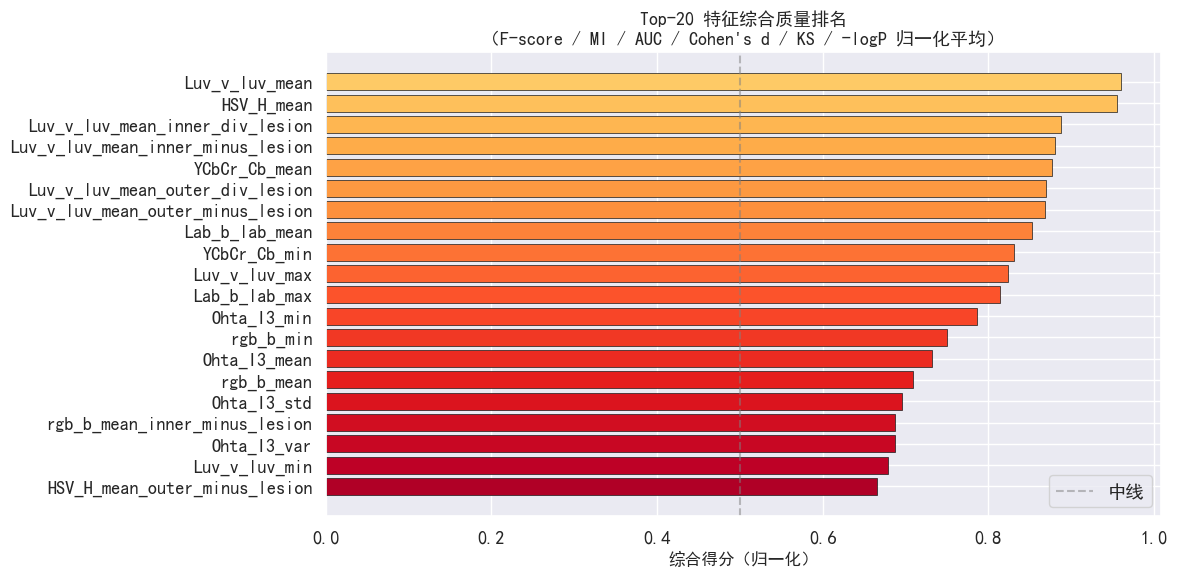

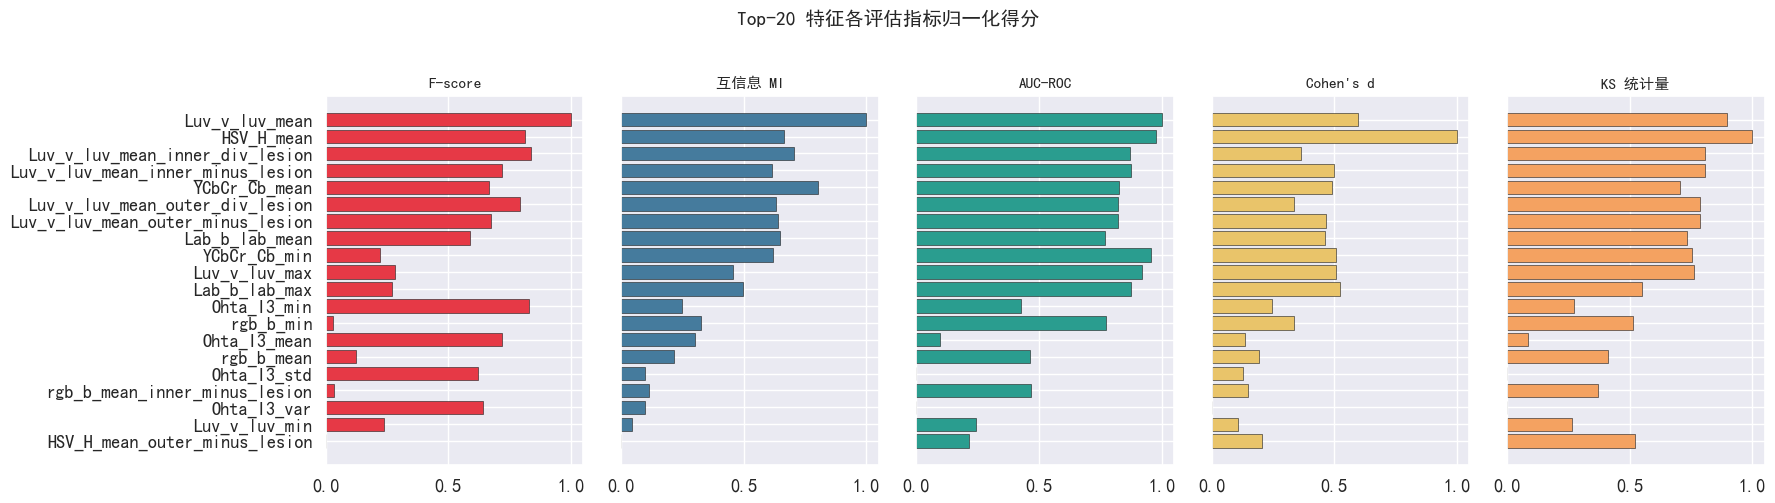

In [9]:

# ---- 4.1 Top-20 特征综合得分条形图 ----
top20 = df_scores.head(20)
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top20)))
bars = ax.barh(top20['feature'][::-1], top20['composite_score'][::-1], color=colors[::-1], edgecolor='k', linewidth=0.5)
ax.set_xlabel('综合得分（归一化）', fontsize=12)
ax.set_title('Top-20 特征综合质量排名\n（F-score / MI / AUC / Cohen\'s d / KS / -logP 归一化平均）', fontsize=13)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='中线')
ax.legend(); plt.tight_layout(); plt.show()

# ---- 4.2 多指标并排条形图 ----
metrics = ['F_score', 'MI', 'AUC', 'Cohens_d', 'KS_stat']
metric_labels = ['F-score', '互信息 MI', 'AUC-ROC', "Cohen's d", 'KS 统计量']

from sklearn.preprocessing import MinMaxScaler
normed_top20 = MinMaxScaler().fit_transform(top20[metrics])

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5), sharey=True)
palette = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261']
for ax, col, label, color, vals in zip(axes, metrics, metric_labels, palette, normed_top20.T):
    ax.barh(top20['feature'][::-1], vals[::-1], color=color, edgecolor='k', linewidth=0.4)
    ax.set_title(label, fontsize=11)
    ax.set_xlim(0, 1.05)

fig.suptitle('Top-20 特征各评估指标归一化得分', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### (2) 可视化--AUC 与 Cohen's d 散点图

这张散点图同时展示每个特征的“分类能力”和“效应大小”。

- 横轴 `Cohen's d`：两类均值差异相对于组内波动的大小。
- 纵轴 `AUC`：单特征阈值分类能力。
- 颜色表示综合得分，颜色越深通常综合质量越高。
- 横向虚线 `AUC=0.7` 表示较有实用价值的单特征分类能力参考线。
- 纵向虚线 `d=0.8` 表示大效应量参考线。

右上角区域的特征最理想：均值差异大，同时单独做分类也有较强区分能力。


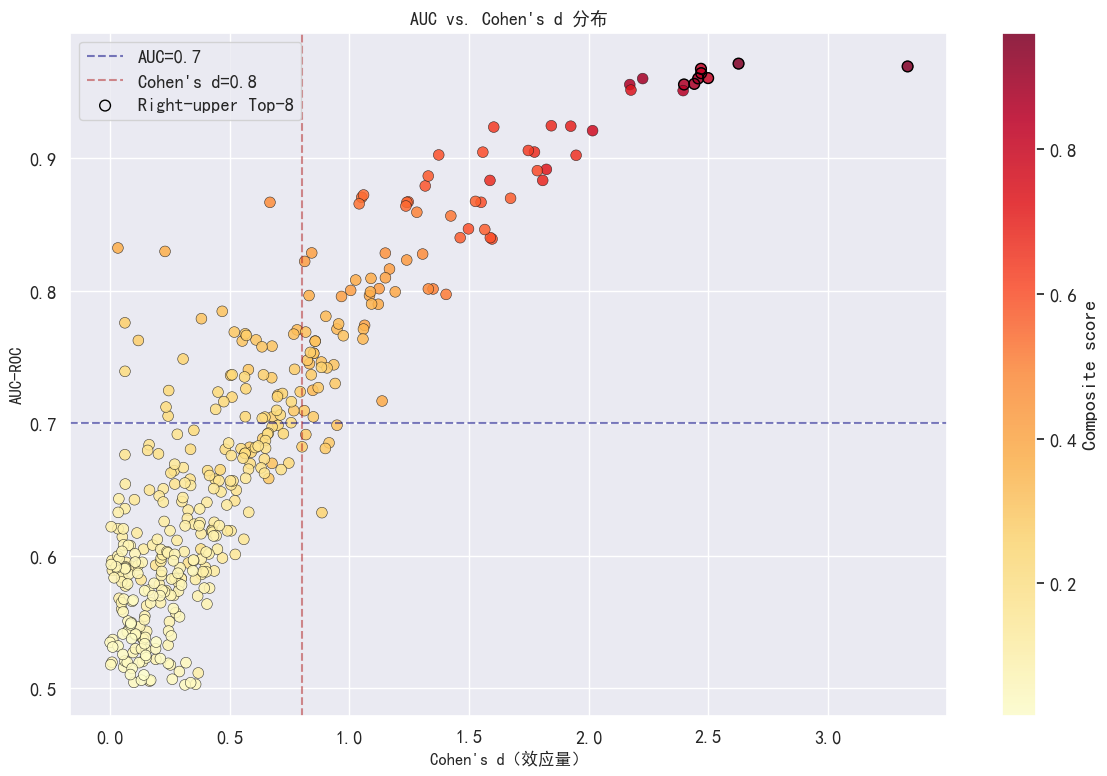

散点图右上角 Top-8 特征如下：
01. HSV_H_mean | AUC = 0.9693 | Cohen's d = 3.3320 | Right-upper score = 1.9954
02. Luv_v_luv_mean | AUC = 0.9714 | Cohen's d = 2.6257 | Right-upper score = 1.7880
03. YCbCr_Cb_min | AUC = 0.9675 | Cohen's d = 2.4686 | Right-upper score = 1.7325
04. Lab_b_lab_max | AUC = 0.9605 | Cohen's d = 2.4986 | Right-upper score = 1.7266
05. Luv_v_luv_max | AUC = 0.9642 | Cohen's d = 2.4695 | Right-upper score = 1.7257
06. Luv_v_luv_mean_inner_minus_lesion | AUC = 0.9602 | Cohen's d = 2.4570 | Right-upper score = 1.7135
07. YCbCr_Cb_mean | AUC = 0.9561 | Cohen's d = 2.4407 | Right-upper score = 1.6999
08. Luv_v_luv_mean_outer_minus_lesion | AUC = 0.9557 | Cohen's d = 2.3978 | Right-upper score = 1.6860


In [19]:
# ---- 4.3 AUC vs. Cohen's d 散点图（全特征） ----
from sklearn.preprocessing import MinMaxScaler

df_plot = df_scores.copy()

# Cohen's d 表示效应量大小，通常取绝对值
df_plot["abs_Cohens_d"] = df_plot["Cohens_d"].abs()

# 归一化 AUC 和 Cohen's d
scaler = MinMaxScaler()
df_plot[["AUC_norm", "d_norm"]] = scaler.fit_transform(
    df_plot[["AUC", "abs_Cohens_d"]]
)

# 计算“靠近右上角”的程度
df_plot["upper_right_score"] = df_plot["AUC_norm"] + df_plot["d_norm"]

# 取右上角 Top-8
top8_upper_right = df_plot.sort_values(
    "upper_right_score",
    ascending=False
).head(8).reset_index(drop=True)


fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(
    df_plot["Cohens_d"],
    df_plot["AUC"],
    c=df_plot["composite_score"],
    cmap="YlOrRd",
    s=60,
    edgecolors="k",
    linewidths=0.4,
    alpha=0.85
)

ax.axhline(0.7, color="navy", linestyle="--", alpha=0.5, label="AUC=0.7")
ax.axvline(0.8, color="firebrick", linestyle="--", alpha=0.5, label="Cohen's d=0.8")

# 只圈出右上角 Top-8，不在图上写文字
ax.scatter(
    top8_upper_right["Cohens_d"],
    top8_upper_right["AUC"],
    s=60,
    facecolors="none",
    edgecolors="black",
    linewidths=1,
    label="Right-upper Top-8"
)

ax.set_xlabel("Cohen's d（效应量）", fontsize=12)
ax.set_ylabel("AUC-ROC", fontsize=12)
ax.set_title("AUC vs. Cohen's d 分布", fontsize=13)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Composite score")

ax.legend()
plt.tight_layout()
plt.show()


# ---- 打印右上角 Top-8 特征 ----
print("=" * 80)
print("散点图右上角 Top-8 特征如下：")
print("=" * 80)

for i, row in top8_upper_right.iterrows():
    print(
        f"{i + 1:02d}. {row['feature']} | "
        f"AUC = {row['AUC']:.4f} | "
        f"Cohen's d = {row['Cohens_d']:.4f} | "
        f"Right-upper score = {row['upper_right_score']:.4f}"
    )

### (3) 可视化--箱式图

这组 12 个子图比较 Top-12 特征在 `vasc` 和 `non-vasc` 两类中的取值分布。

- 箱线图显示中位数、四分位数和离群点。
- 叠加的散点显示每个样本的实际取值，能观察类别内部离散程度和样本重叠。
- 每个小标题列出该特征的 `AUC`、`Cohen's d` 和 `MW_pvalue`。

如果两类箱体明显分离、散点重叠少，说明这个特征对分类更有帮助。如果箱体重叠严重，即使 p 值显著，也可能只是样本量导致的统计显著，实际分类价值有限。


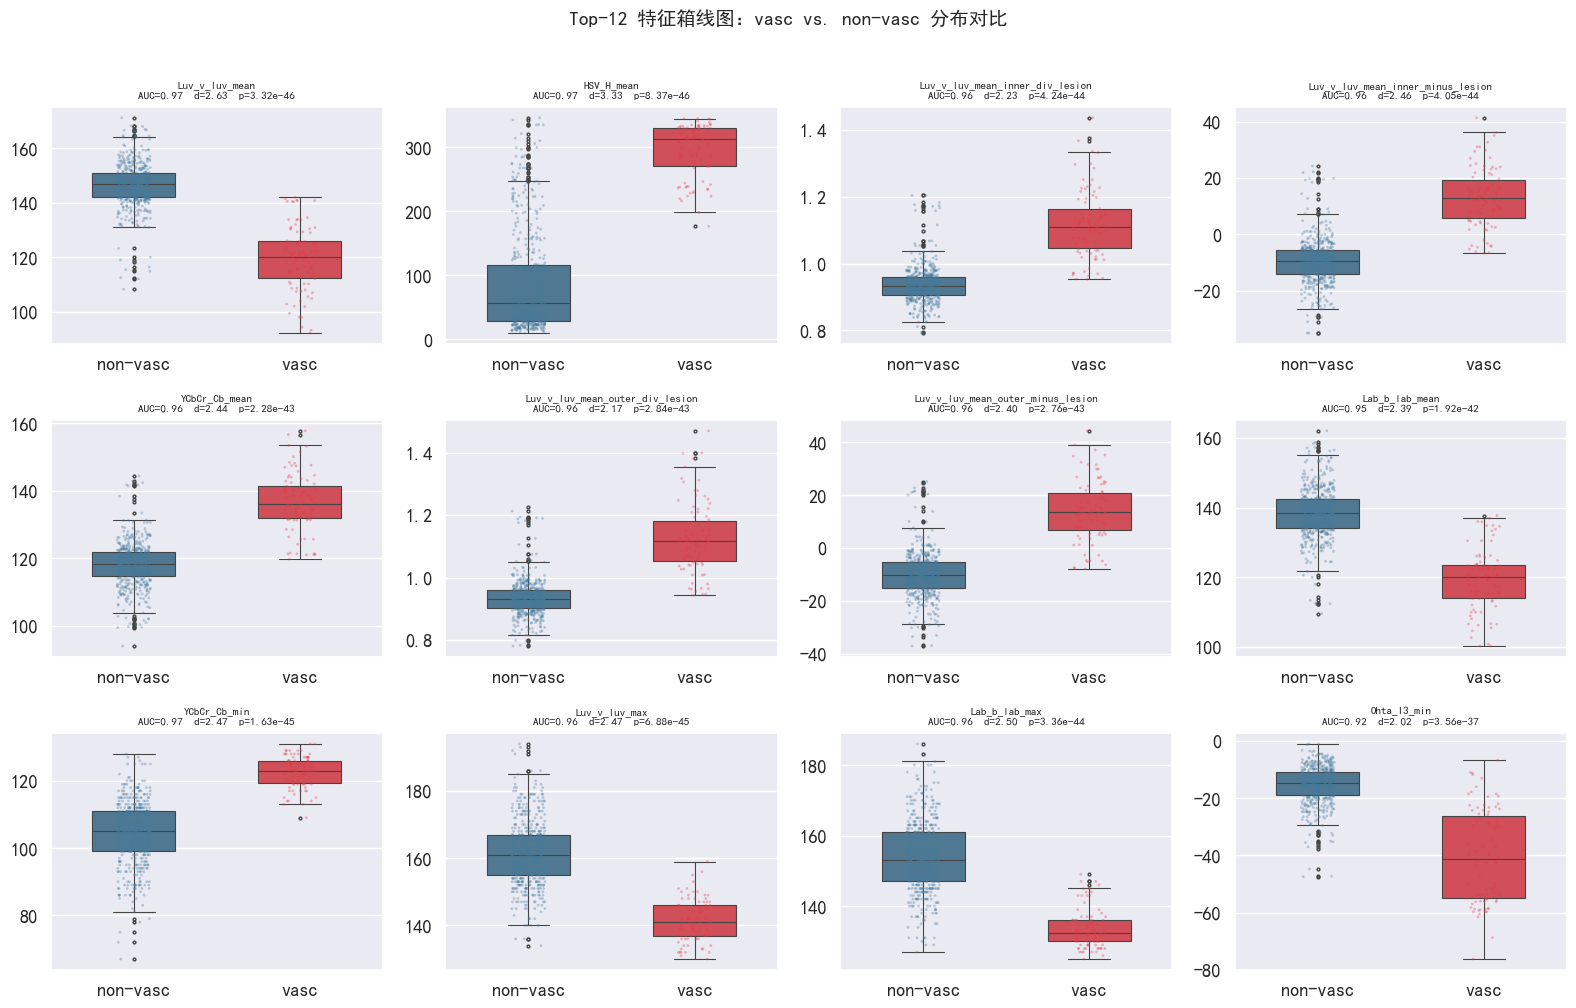

In [14]:
# ---- 4.4 Top-12 特征的箱线图：vasc vs. non-vasc 分布对比 ----
top12_feats = df_scores.head(12)['feature'].tolist()
df_plot = df_feat[top12_feats].copy()
df_plot['class'] = pd.Series(labels, index=df_feat.index).map({0:'non-vasc', 1:'vasc'})

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
palette_box = {'vasc': '#E63946', 'non-vasc': '#457B9D'}

for ax, feat in zip(axes, top12_feats):
    sns.boxplot(data=df_plot, x='class', y=feat, palette=palette_box, ax=ax,
                width=0.5, linewidth=0.8, fliersize=2)
    # 叠加抖散点
    sns.stripplot(data=df_plot, x='class', y=feat, palette=palette_box, ax=ax,
                  size=2, alpha=0.35, jitter=True)

    row = df_scores[df_scores['feature'] == feat].iloc[0]
    ax.set_title(f'{feat}\nAUC={row["AUC"]:.2f}  d={row["Cohens_d"]:.2f}  p={row["MW_pvalue"]:.2e}',
                 fontsize=8)
    ax.set_xlabel(''); ax.set_ylabel('')

fig.suptitle('Top-12 特征箱线图：vasc vs. non-vasc 分布对比', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### (4) 可视化--KDE 密度分布对比

KDE 图展示 Top-6 特征在两类样本中的平滑概率密度。

- 蓝色区域是 `non-vasc`，红色区域是 `vasc`。
- 曲线峰值的位置表示该类样本常见的取值范围。
- 两条曲线分离越明显，特征越容易用阈值区分两类。
- 标题中的 `AUC` 反映单特征分类能力，`KS` 反映两类整体分布差异。

相比箱线图，KDE 更容易看出分布是否多峰、是否存在长尾，以及两类重叠主要发生在哪个取值区间。


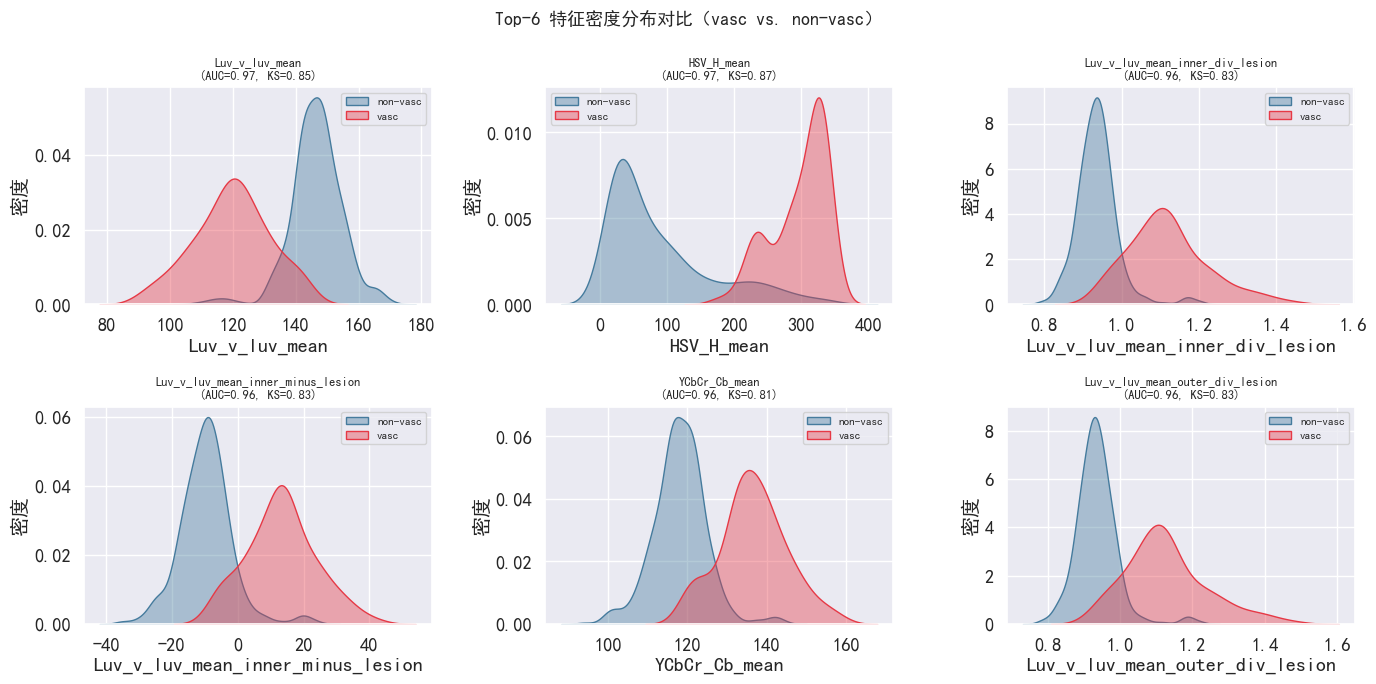

In [15]:
# ---- 4.5 Top-6 特征 KDE 密度对比图 ----
top6 = df_scores.head(6)['feature'].tolist()
vasc_data    = df_feat[labels == 1]
nonvasc_data = df_feat[labels == 0]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for ax, feat in zip(axes, top6):
    sns.kdeplot(nonvasc_data[feat], ax=ax, label='non-vasc', color='#457B9D', fill=True, alpha=0.4)
    sns.kdeplot(vasc_data[feat],    ax=ax, label='vasc',     color='#E63946', fill=True, alpha=0.4)
    row = df_scores[df_scores['feature'] == feat].iloc[0]
    ax.set_title(f'{feat}\n(AUC={row["AUC"]:.2f}, KS={row["KS_stat"]:.2f})', fontsize=9)
    ax.legend(fontsize=8); ax.set_ylabel('密度')

fig.suptitle('Top-6 特征密度分布对比（vasc vs. non-vasc）', fontsize=13)
plt.tight_layout(); plt.show()

## 第四节： 多变量评估--相关性分析

### （1） 特征相关性热力图

Pearson 相关系数，用于判断冗余。

- 数值接近 `1` 表示两个特征高度正相关，可能表达相似信息。
- 数值接近 `-1` 表示高度负相关，也可能存在冗余。
- 数值接近 `0` 表示线性相关弱。
- 代码只显示下三角矩阵，避免重复。

这个图的核心用途是特征筛选：如果两个高分特征相关系数超过 0.9，通常可以保留综合分更高或更易解释的一个，减少模型冗余和过拟合风险。



前面的 Pearson 相关性主要反映线性关系。但图像特征经常存在偏态分布、长尾分布或非线性单调关系，因此这里补充 Spearman 相关性。

筛选冗余特征时，建议同时参考：

- `abs(Pearson) > 0.90`：线性高度相关；
- `abs(Spearman) > 0.90`：单调高度相关。

如果两个特征高度相关，一般保留综合得分更高、可解释性更强或与病理视觉特征更一致的一个。

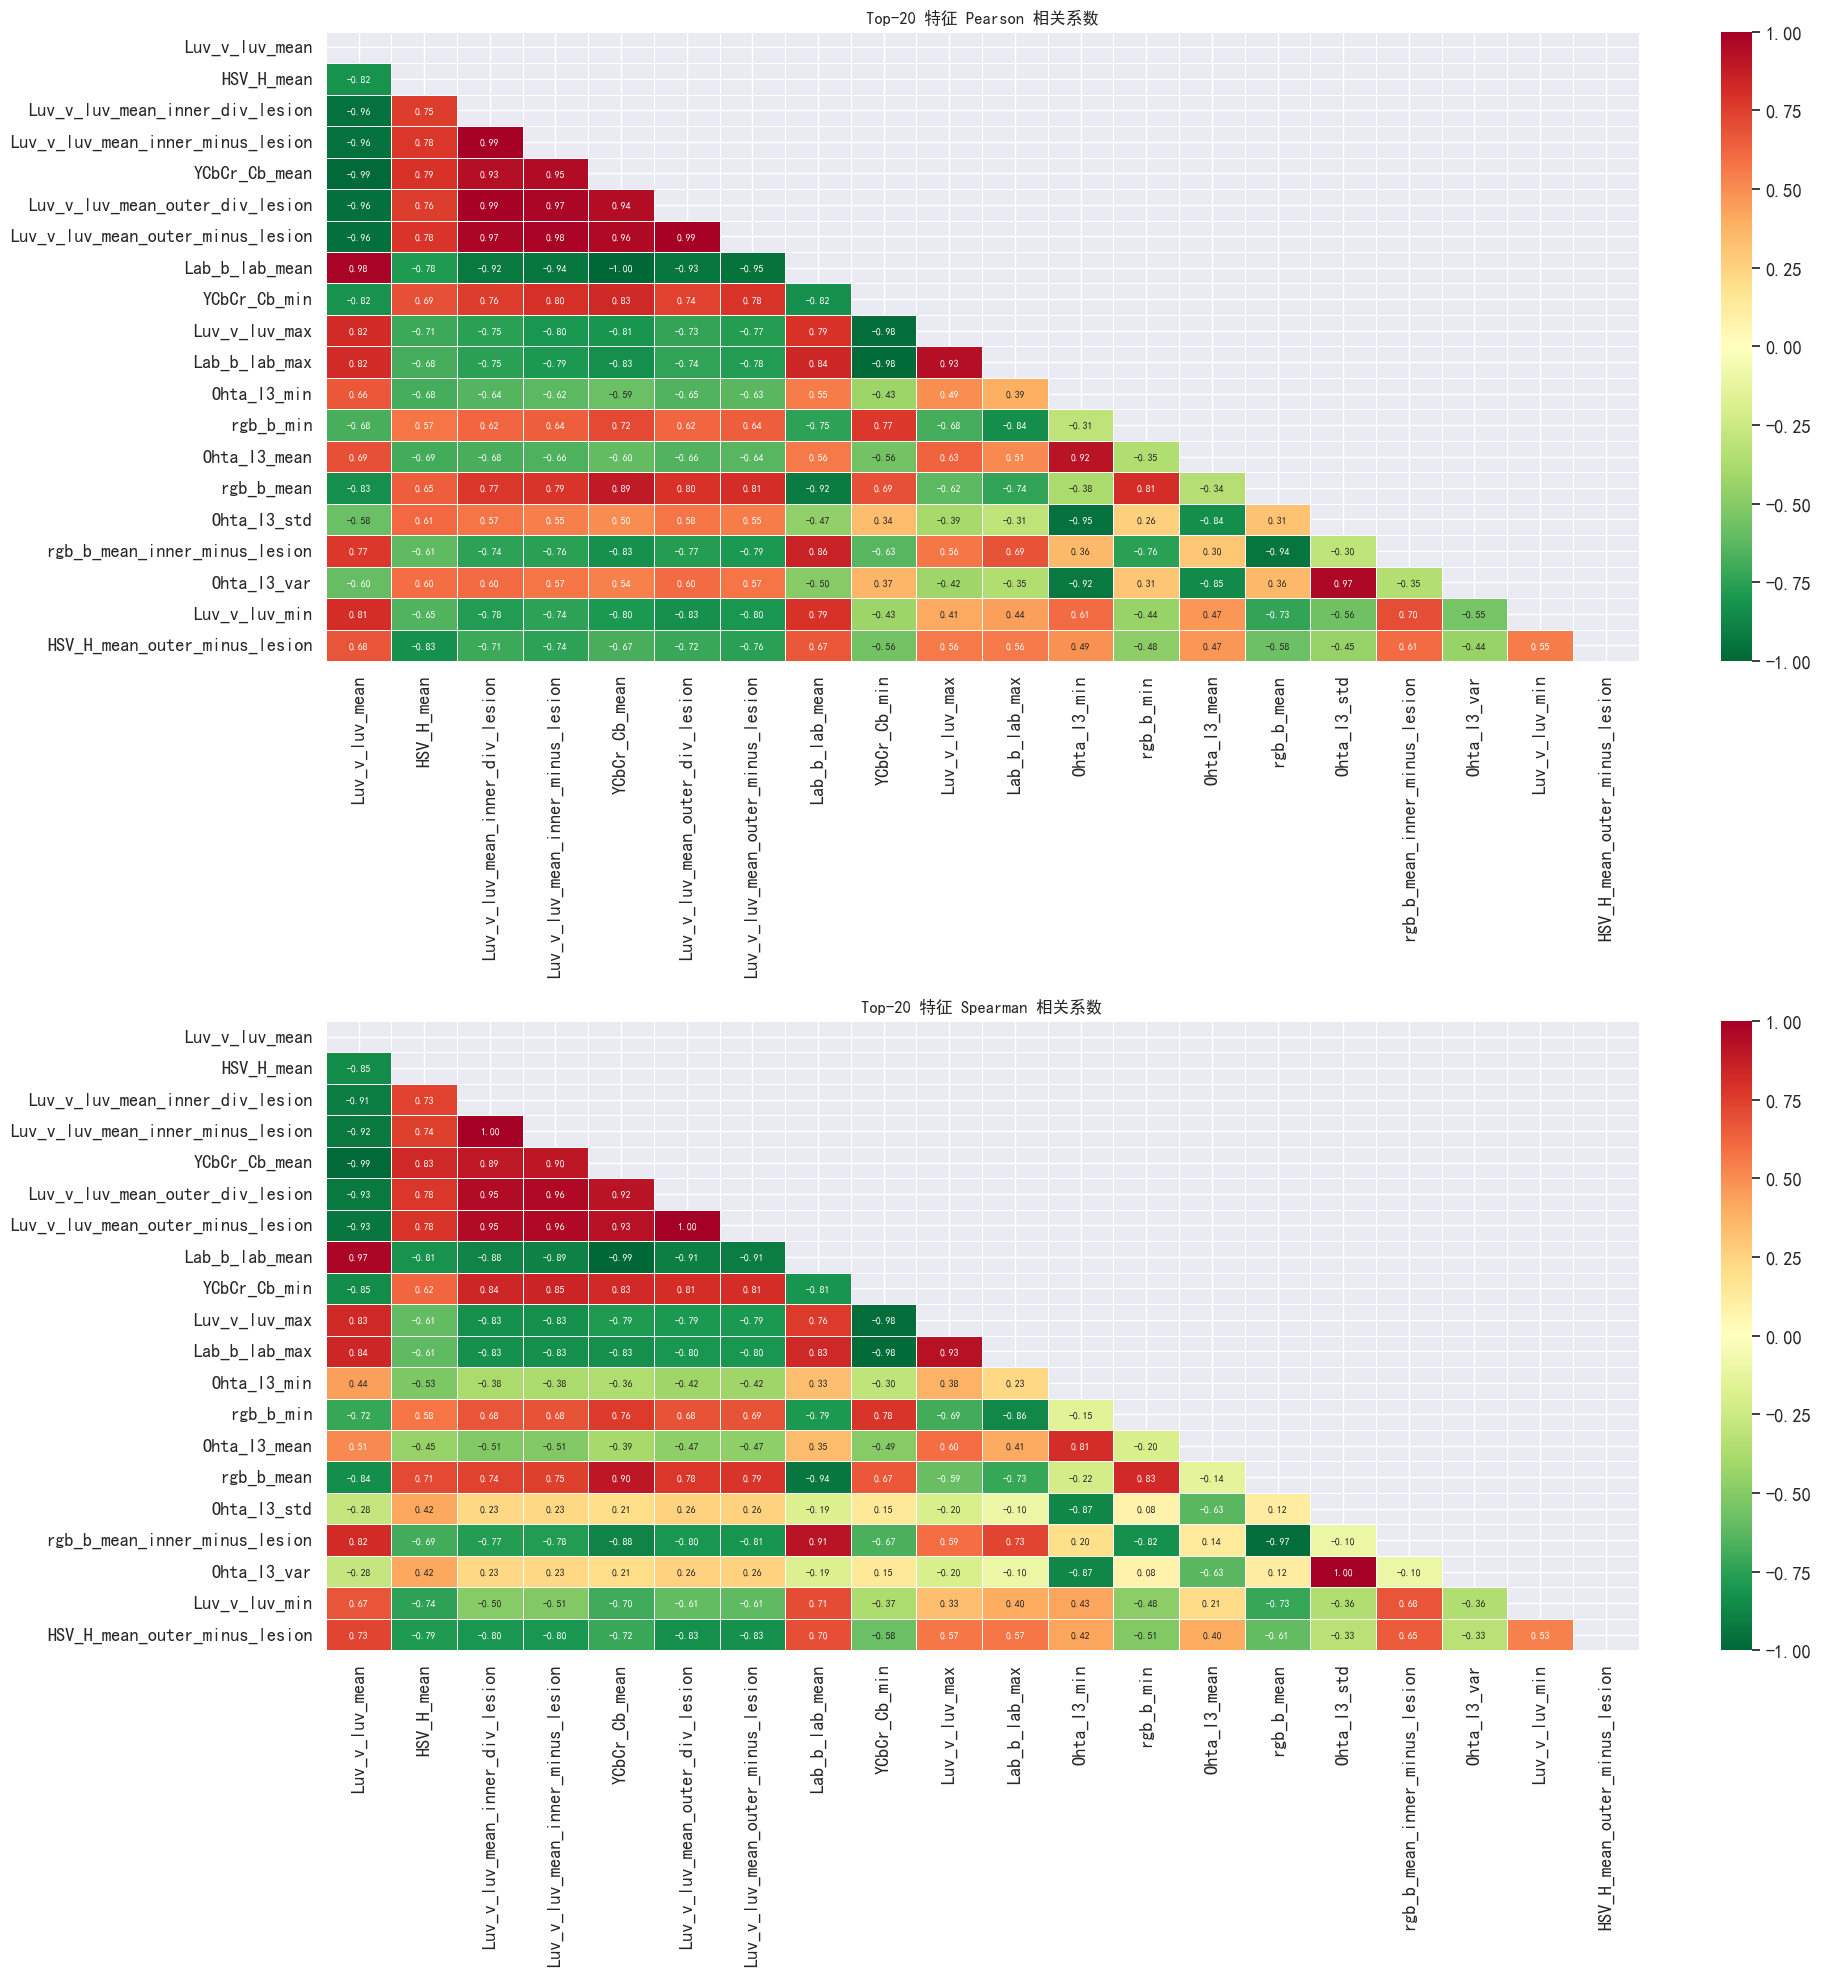

Pearson |r| >= 0.90 的高相关特征对：


,feature_1,feature_2,corr,abs_corr
0,YCbCr_Cb_mean,Lab_b_lab_mean,-0.995132,0.995132
1,Luv_v_luv_mean_inner_div_lesion,Luv_v_luv_mean_inner_minus_lesion,0.988667,0.988667
2,Luv_v_luv_mean_outer_div_lesion,Luv_v_luv_mean_outer_minus_lesion,0.988247,0.988247
3,Luv_v_luv_mean,YCbCr_Cb_mean,-0.987927,0.987927
4,Luv_v_luv_mean_inner_div_lesion,Luv_v_luv_mean_outer_div_lesion,0.987602,0.987602
5,Luv_v_luv_mean_inner_minus_lesion,Luv_v_luv_mean_outer_minus_lesion,0.983215,0.983215
6,YCbCr_Cb_min,Lab_b_lab_max,-0.978378,0.978378
7,Luv_v_luv_mean,Lab_b_lab_mean,0.977983,0.977983
8,YCbCr_Cb_min,Luv_v_luv_max,-0.976143,0.976143
9,Luv_v_luv_mean_inner_div_lesion,Luv_v_luv_mean_outer_minus_lesion,0.974080,0.974080



Spearman |rho| >= 0.90 的高相关特征对：


,feature_1,feature_2,corr,abs_corr
0,Ohta_I3_std,Ohta_I3_var,1.000000,1.000000
1,Luv_v_luv_mean_outer_div_lesion,Luv_v_luv_mean_outer_minus_lesion,0.999694,0.999694
2,Luv_v_luv_mean_inner_div_lesion,Luv_v_luv_mean_inner_minus_lesion,0.999532,0.999532
3,YCbCr_Cb_mean,Lab_b_lab_mean,-0.993450,0.993450
4,Luv_v_luv_mean,YCbCr_Cb_mean,-0.986913,0.986913
5,YCbCr_Cb_min,Lab_b_lab_max,-0.979177,0.979177
6,YCbCr_Cb_min,Luv_v_luv_max,-0.976352,0.976352
7,rgb_b_mean,rgb_b_mean_inner_minus_lesion,-0.973273,0.973273
8,Luv_v_luv_mean,Lab_b_lab_mean,0.969862,0.969862
9,Luv_v_luv_mean_inner_minus_lesion,Luv_v_luv_mean_outer_div_lesion,0.956103,0.956103


In [16]:
# ---- Pearson + Spearman 相关性联合分析 ----
top20_feats = df_scores.head(20)['feature'].tolist()

corr_pearson = df_feat[top20_feats].corr(method='pearson')
corr_spearman = df_feat[top20_feats].corr(method='spearman')

fig, axes = plt.subplots(2, 1, figsize=(20, 20))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=axes[0], annot_kws={'size': 7},
            vmin=-1, vmax=1)
axes[0].set_title('Top-20 特征 Pearson 相关系数', fontsize=12)

sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=axes[1], annot_kws={'size': 7},
            vmin=-1, vmax=1)
axes[1].set_title('Top-20 特征 Spearman 相关系数', fontsize=12)

plt.tight_layout()
plt.show()


def list_high_corr_pairs(corr_matrix, threshold=0.90):
    """列出相关矩阵中绝对相关系数超过阈值的特征对。"""
    pairs = []
    cols = corr_matrix.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append({
                    'feature_1': cols[i],
                    'feature_2': cols[j],
                    'corr': r,
                    'abs_corr': abs(r)
                })
    return pd.DataFrame(pairs).sort_values('abs_corr', ascending=False).reset_index(drop=True)

pearson_high = list_high_corr_pairs(corr_pearson, threshold=0.90)
spearman_high = list_high_corr_pairs(corr_spearman, threshold=0.90)

print('Pearson |r| >= 0.90 的高相关特征对：')
display(pearson_high)
print('\nSpearman |rho| >= 0.90 的高相关特征对：')
display(spearman_high)

### （1.2）PCA 可视化：用于辅助理解，不作为最终筛选主依据

PCA 的作用是把多个特征投影到低维空间，观察 `vasc` 和 `non-vasc` 是否在整体特征结构上存在分离趋势。

但是：

1. PCA 是无监督方法，不使用标签，因此不能直接代表分类效果；
2. PCA 得到的是主成分，不是原始特征，解释性弱于原始颜色/纹理/形状特征；
3. 所以 PCA 只作为可视化和冗余诊断，不作为最终筛选主方法。


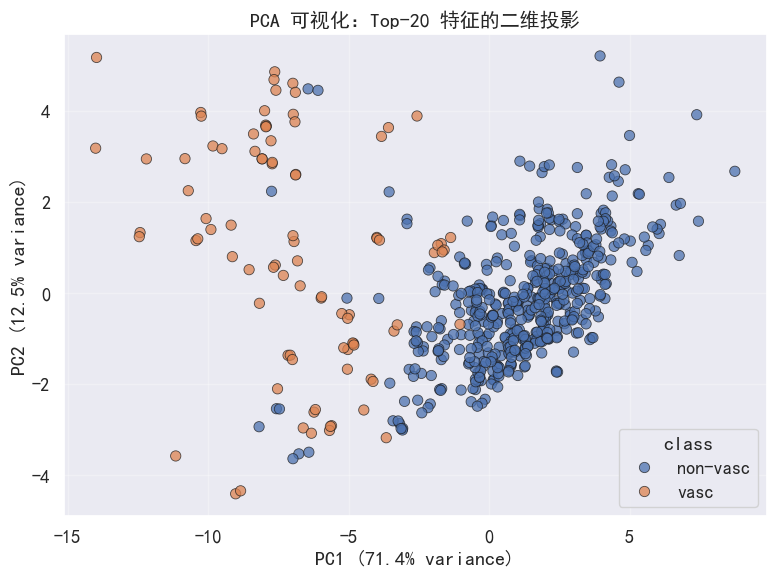

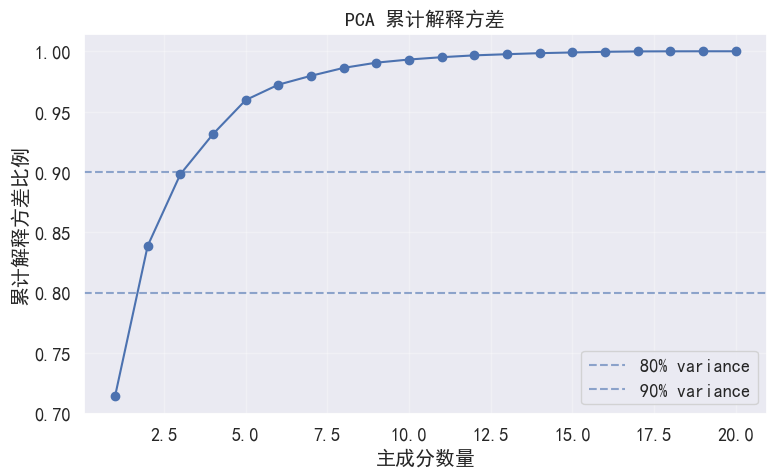

PC1 贡献最大的 Top-10 原始特征：


,PC1_loading,PC2_loading,PC1_abs,PC2_abs
Luv_v_luv_mean,0.259661,0.022665,0.259661,0.022665
YCbCr_Cb_mean,-0.256937,-0.090918,0.256937,0.090918
Luv_v_luv_mean_outer_minus_lesion,-0.256025,-0.033186,0.256025,0.033186
Lab_b_lab_mean,0.254764,0.124823,0.254764,0.124823
Luv_v_luv_mean_inner_minus_lesion,-0.254625,-0.032454,0.254625,0.032454
Luv_v_luv_mean_outer_div_lesion,-0.253347,-0.001998,0.253347,0.001998
Luv_v_luv_mean_inner_div_lesion,-0.252260,0.000130,0.252260,0.000130
HSV_H_mean,-0.226609,0.079102,0.226609,0.079102
rgb_b_mean,-0.222508,-0.227246,0.222508,0.227246
Lab_b_lab_max,0.222432,0.214869,0.222432,0.214869



PC2 贡献最大的 Top-10 原始特征：


,PC1_loading,PC2_loading,PC1_abs,PC2_abs
Ohta_I3_std,-0.168514,0.461664,0.168514,0.461664
Ohta_I3_var,-0.174692,0.432901,0.174692,0.432901
Ohta_I3_min,0.187725,-0.424684,0.187725,0.424684
Ohta_I3_mean,0.191290,-0.363289,0.191290,0.363289
rgb_b_min,-0.194358,-0.245734,0.194358,0.245734
rgb_b_mean,-0.222508,-0.227246,0.222508,0.227246
rgb_b_mean_inner_minus_lesion,0.212311,0.219419,0.212311,0.219419
Lab_b_lab_max,0.222432,0.214869,0.222432,0.214869
YCbCr_Cb_min,-0.222237,-0.177878,0.222237,0.177878
Lab_b_lab_mean,0.254764,0.124823,0.254764,0.124823


In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 使用 Top-20 特征进行 PCA 可视化
pca_feats = df_scores.head(20)['feature'].tolist()
X_pca = df_feat[pca_feats].replace([np.inf, -np.inf], np.nan).fillna(0)
X_scaled = StandardScaler().fit_transform(X_pca)

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    'PC1': X_2d[:, 0],
    'PC2': X_2d[:, 1],
    'class': pd.Series(labels, index=df_feat.index).map({0: 'non-vasc', 1: 'vasc'}),
    'dx': df_meta_valid['dx'].values,
    'base_id': df_meta_valid['base_id'].values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='class',
    alpha=0.75,
    s=55,
    edgecolor='k'
)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% variance)')
plt.title('PCA 可视化：Top-20 特征的二维投影')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 累计解释方差：判断需要多少主成分可以解释大部分特征方差
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.80, linestyle='--', alpha=0.6, label='80% variance')
plt.axhline(0.90, linestyle='--', alpha=0.6, label='90% variance')
plt.xlabel('主成分数量')
plt.ylabel('累计解释方差比例')
plt.title('PCA 累计解释方差')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 查看 PC1 / PC2 主要由哪些原始特征贡献，便于解释 PCA 图
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=pca_feats,
    columns=['PC1_loading', 'PC2_loading']
)
loadings['PC1_abs'] = loadings['PC1_loading'].abs()
loadings['PC2_abs'] = loadings['PC2_loading'].abs()

print('PC1 贡献最大的 Top-10 原始特征：')
display(loadings.sort_values('PC1_abs', ascending=False).head(10))
print('\nPC2 贡献最大的 Top-10 原始特征：')
display(loadings.sort_values('PC2_abs', ascending=False).head(10))

## 第五节：如何确定最终特征和数量？

最终特征数量不建议手动固定成 Top-10 或 Top-20。更合理的方法是把“特征数量”当成一个超参数，比较不同候选数量下的表现。

1. 先按照前面得到的综合得分对特征排序；
2. 依次测试 Top-5、Top-8、Top-10、Top-12、Top-15、Top-20 等候选集合；

```python
# 候选 Top-k 数量
k_list = [5, 8, 10, 12, 15, 20, 25, 30,35, 40, 45, 50]  #可以修改
```
4. 每个集合内部先做相关性去冗余；
5. 使用 GroupKFold / StratifiedGroupKFold，按 base_id 分组交叉验证；
6. 观察验证集 ROC-AUC、Balanced Accuracy、F1、PR-AUC 随特征数量变化；
7. 选择性能接近最优、但特征数量更少的方案。


交叉验证方式： StratifiedGroupKFold


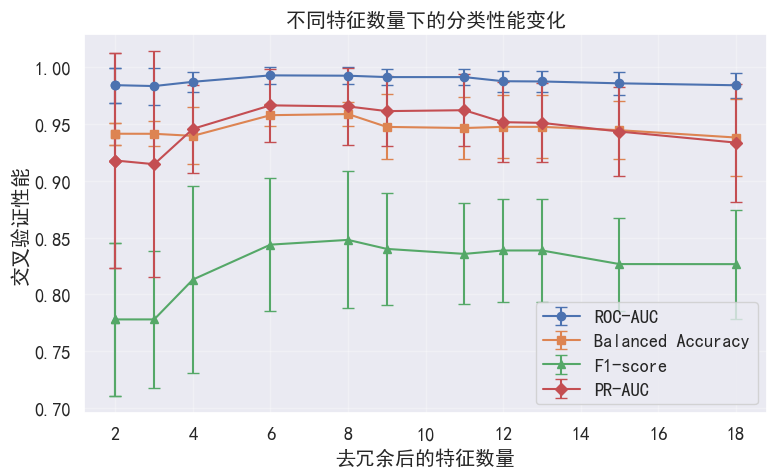

最终特征数量选择结果
最高平均 ROC-AUC：0.9929
允许的 AUC 容忍范围：0.0100
最终选择的去冗余后特征数量：2
该方案平均 ROC-AUC：0.9843 ± 0.0153
该方案 Balanced Accuracy：0.9415 ± 0.0099
该方案 F1-score：0.7780 ± 0.0677
该方案 PR-AUC：0.9179 ± 0.0950

最终确定的特征如下：
01. Luv_v_luv_mean
02. HSV_H_mean


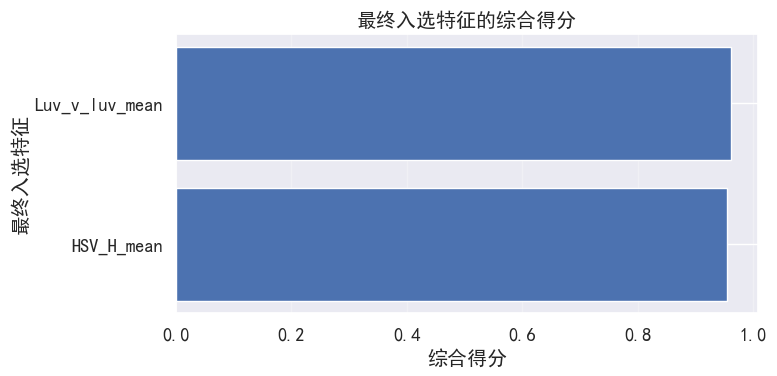

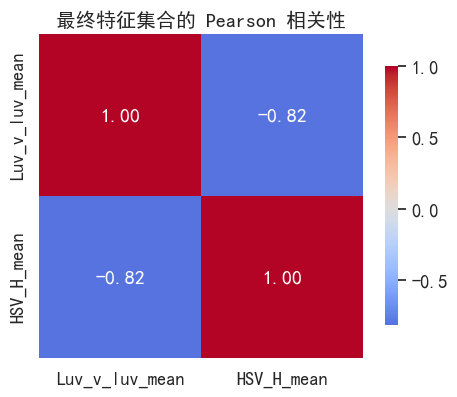

In [25]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    average_precision_score
)

# ------------------------------------------------------------
# 5.1 定义相关性去冗余函数
# ------------------------------------------------------------

def remove_high_corr_features_by_score(feature_list, df_feat, df_scores, threshold=0.90):
    """
    按综合得分排序后的 feature_list 依次遍历。
    如果当前特征与已保留特征高度相关，则删除当前特征。
    
    这样做的含义是：
    - 高排名特征优先保留；
    - 与高排名特征高度重复的低排名特征被删除；
    - 保证最终特征集合既有较强判别力，也不过度冗余。
    """
    selected = []
    removed_pairs = []

    for feat in feature_list:
        keep = True

        for kept_feat in selected:
            r = df_feat[[feat, kept_feat]].corr(method='pearson').iloc[0, 1]

            if abs(r) >= threshold:
                keep = False
                removed_pairs.append({
                    'removed_feature': feat,
                    'kept_feature': kept_feat,
                    'corr': r
                })
                break

        if keep:
            selected.append(feat)

    return selected, pd.DataFrame(removed_pairs)


# ------------------------------------------------------------
# 5.2 准备标签、分组和候选特征数量
# ------------------------------------------------------------

X_all = df_feat.copy()
y = np.array(labels)

# base_id 用于防止增强图像泄漏
groups = df_meta_valid['base_id'].values

# 候选 Top-k 数量
k_list = [5, 8, 10, 12, 15, 20, 25, 30,35, 40, 45, 50]

# 最多不能超过当前特征数
k_list = [k for k in k_list if k <= len(df_scores)]

results = []

# 尽量使用 StratifiedGroupKFold；
# 如果 sklearn 版本不支持或数据不适合，则退回 GroupKFold。
try:
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    use_stratified_group = True
except Exception:
    cv = GroupKFold(n_splits=5)
    use_stratified_group = False

print("交叉验证方式：", "StratifiedGroupKFold" if use_stratified_group else "GroupKFold")


# ------------------------------------------------------------
# 5.3 遍历不同 Top-k 特征数量，并进行交叉验证
# ------------------------------------------------------------

for k in k_list:
    # 先按照综合得分取 Top-k
    ranked_feats = df_scores.head(k)['feature'].tolist()

    # 再进行相关性去冗余
    selected_feats, removed_corr_pairs = remove_high_corr_features_by_score(
        ranked_feats,
        df_feat=X_all,
        df_scores=df_scores,
        threshold=0.90
    )

    X_k = X_all[selected_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

    auc_list = []
    bacc_list = []
    f1_list = []
    pr_auc_list = []

    if use_stratified_group:
        split_iter = cv.split(X_k, y, groups)
    else:
        split_iter = cv.split(X_k, y, groups)

    for train_idx, test_idx in split_iter:
        X_train, X_test = X_k.iloc[train_idx], X_k.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                class_weight='balanced',
                max_iter=3000,
                solver='liblinear',
                random_state=42
            ))
        ])

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        # 某些极端折中可能只有一个类别，AUC 会报错，因此做保护
        try:
            auc = roc_auc_score(y_test, y_prob)
        except ValueError:
            auc = np.nan

        try:
            pr_auc = average_precision_score(y_test, y_prob)
        except ValueError:
            pr_auc = np.nan

        auc_list.append(auc)
        pr_auc_list.append(pr_auc)
        bacc_list.append(balanced_accuracy_score(y_test, y_pred))
        f1_list.append(f1_score(y_test, y_pred, zero_division=0))

    results.append({
        'top_k_input': k,
        'n_after_corr_filter': len(selected_feats),
        'selected_features': selected_feats,
        'auc_mean': np.nanmean(auc_list),
        'auc_std': np.nanstd(auc_list),
        'bacc_mean': np.nanmean(bacc_list),
        'bacc_std': np.nanstd(bacc_list),
        'f1_mean': np.nanmean(f1_list),
        'f1_std': np.nanstd(f1_list),
        'pr_auc_mean': np.nanmean(pr_auc_list),
        'pr_auc_std': np.nanstd(pr_auc_list)
    })

df_k = pd.DataFrame(results)


# ------------------------------------------------------------
# 5.4 可视化：不同特征数量下的模型性能
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.errorbar(
    df_k['n_after_corr_filter'],
    df_k['auc_mean'],
    yerr=df_k['auc_std'],
    marker='o',
    capsize=4,
    label='ROC-AUC'
)

plt.errorbar(
    df_k['n_after_corr_filter'],
    df_k['bacc_mean'],
    yerr=df_k['bacc_std'],
    marker='s',
    capsize=4,
    label='Balanced Accuracy'
)

plt.errorbar(
    df_k['n_after_corr_filter'],
    df_k['f1_mean'],
    yerr=df_k['f1_std'],
    marker='^',
    capsize=4,
    label='F1-score'
)

plt.errorbar(
    df_k['n_after_corr_filter'],
    df_k['pr_auc_mean'],
    yerr=df_k['pr_auc_std'],
    marker='D',
    capsize=4,
    label='PR-AUC'
)

plt.xlabel('去冗余后的特征数量')
plt.ylabel('交叉验证性能')
plt.title('不同特征数量下的分类性能变化')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5.5 自动选择最终特征数量
# ------------------------------------------------------------
#
# 选择原则：
# 1. 先找到 ROC-AUC 最高的方案；
# 2. 在 AUC 距离最高值不超过 0.01 的方案中，
#    选择特征数量最少的方案；
# 3. 这样可以避免为了极小的性能提升而加入过多特征。

best_auc = df_k['auc_mean'].max()
auc_tolerance = 0.01

candidate_rows = df_k[df_k['auc_mean'] >= best_auc - auc_tolerance].copy()

# 优先选择特征更少的方案
candidate_rows = candidate_rows.sort_values(
    by=['n_after_corr_filter', 'auc_mean'],
    ascending=[True, False]
)

best_row = candidate_rows.iloc[0]

final_n_features = int(best_row['n_after_corr_filter'])
final_features_auto = best_row['selected_features']

print("=" * 70)
print("最终特征数量选择结果")
print("=" * 70)
print(f"最高平均 ROC-AUC：{best_auc:.4f}")
print(f"允许的 AUC 容忍范围：{auc_tolerance:.4f}")
print(f"最终选择的去冗余后特征数量：{final_n_features}")
print(f"该方案平均 ROC-AUC：{best_row['auc_mean']:.4f} ± {best_row['auc_std']:.4f}")
print(f"该方案 Balanced Accuracy：{best_row['bacc_mean']:.4f} ± {best_row['bacc_std']:.4f}")
print(f"该方案 F1-score：{best_row['f1_mean']:.4f} ± {best_row['f1_std']:.4f}")
print(f"该方案 PR-AUC：{best_row['pr_auc_mean']:.4f} ± {best_row['pr_auc_std']:.4f}")

print("\n最终确定的特征如下：")
for i, feat in enumerate(final_features_auto, 1):
    print(f"{i:02d}. {feat}")


# ------------------------------------------------------------
# 5.6 可视化：最终特征的综合得分
# ------------------------------------------------------------

final_score_df = df_scores[df_scores['feature'].isin(final_features_auto)].copy()

# 保持最终特征的顺序
final_score_df['feature'] = pd.Categorical(
    final_score_df['feature'],
    categories=final_features_auto,
    ordered=True
)

final_score_df = final_score_df.sort_values('feature')

plt.figure(figsize=(8, max(4, 0.35 * len(final_features_auto))))

plt.barh(
    final_score_df['feature'],
    final_score_df['composite_score']
)

plt.xlabel('综合得分')
plt.ylabel('最终入选特征')
plt.title('最终入选特征的综合得分')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5.7 可视化：最终特征相关性热力图
# ------------------------------------------------------------

plt.figure(figsize=(0.6 * final_n_features + 4, 0.6 * final_n_features + 3))

corr_final = X_all[final_features_auto].corr(method='pearson')

sns.heatmap(
    corr_final,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('最终特征集合的 Pearson 相关性')
plt.tight_layout()
plt.show()